In [10]:
def derivative_value(q, u, k, E):
    return (2*q**3 - (2*k**2 + 2*u)*q + 2*k*E) / (E - 2*k*q)

def get_all_roots(u, k, const, E):
    a = -1
    b = 0
    c = 2*k**2 + 2*u
    d = -4*k*E
    e = E**2 - u**2 - const**2 + 2*k**2*u - k**4
    
  
    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    

    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
 
    all_real_roots = all(-1e-12 < abs(root.imag) < 1e-12 for root in roots_sorted)
    
    if all_real_roots:
     
        q_positive = []  # 导数 >= 0 的根
        q_negative = []  # 导数 < 0 的根
        
        for root in roots_sorted:
            # 使用实部计算导数
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)
        
        # 排序（按实部）
        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)
        
        # 分类
        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]

    else:
        if E<0 and k>0:
        
            q22, q11, q44, q33= roots_sorted
        if E>0 and k>0:
        
            q11, q22, q33, q44 = roots_sorted
        if E<0 and k<0:
       
            q22, q11, q44, q33 = roots_sorted
        if E>0 and k<0:
        
            q11, q22, q33, q44 = roots_sorted

    return q11, q22, q33, q44

def derivative_value(q, u, k, E):
    return (2*q**3 - (2*k**2 + 2*u)*q + 2*k*E) / (E - 2*k*q)

def get_all_roots_1(u, k, E):

    a = -1
    b = 0
    c = 2*k**2 + 2*u
    d = -4*k*E
    e = E**2 - u**2 + 2*k**2*u - k**4

    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    

    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    

    all_real_roots = all(-1e-10 < abs(root.imag) < 1e-10 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  
        q_negative = []  
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)
        

        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)
        
   
        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]
    else:
        if E<0 and k>0:
            q22, q11, q33, q44 = roots_sorted
        if E>0 and k>0:
      
            q11, q22, q44, q33 = roots_sorted
        if E<0 and k<0:
       
            q22, q11, q33, q44 = roots_sorted
        if E>0 and k<0:
       
            q11, q22, q33, q44 = roots_sorted

    return q11, q22, q33, q44


In [26]:
import numpy as np
import matplotlib.pyplot as plt
def calculate_probabilities_new_method(u, k, Z, E_set):
    const = u/1000
    H = 2*Z*(u)**0.5 
    
    a_set = []
    b_set = []
    c_set = []
    d_set = []
    z_set = []
    
    for E in E_set:  
        qwei = -abs(get_all_roots_1(u, k, E)[2])
        bf1 = 0
        bf2 = 1

        q3 = abs(get_all_roots(u, k, const, E)[1].real)+1j*abs(get_all_roots(u, k, const, E)[1].imag)

        af1 = -const/(((q3+k)**2-u-E)**2+const**2)**0.5
        af2 = ((q3+k)**2-u-E)/(((q3+k)**2-u-E)**2+const**2)**0.5

        q4 =  abs(get_all_roots(u, k, const, E)[3].real)+1j*abs(get_all_roots(u, k, const, E)[3].imag)
        cf1 = (-(q4-k)**2+u-E)/((-(q4-k)**2+u-E)**2+const**2)**0.5
        cf2 = -const/((-(q4-k)**2+u-E)**2+const**2)**0.5

        q_e = abs(get_all_roots_1(u, k, E)[0])
        q_h = abs(get_all_roots_1(u, k, E)[2])

        dd1 = (qwei - q_h)*bf2 - ((q4 - q_h - H/(1j))*cf2*bf1*(qwei + q_e))/((q4 + q_e - H/(1j))*cf1)
        dd2 = (-1*q_e + q3 + H/(1j))*(q4 -q_h - H/(1j))*cf2*af1/((q4 + q_e - H/(1j))*cf1) + (-q_h -q3 + H/(1j))*af2
        
        d1 = dd1/dd2
        c1 = (d1*((-q_e + q3 - H/(1j))*af1) + (qwei + qwei)*bf1)/((q4 + q_e - H/(1j))*cf1)
        b1 = c1*cf1 + d1*af1 - bf1
        a1 = c1*cf2 + d1*af2 - bf2

        d11 = abs(d1)**2 * (abs(af2)**2 - abs(af1)**2) * q3.real / q_e
        c11 = abs(c1)**2 * (abs(cf1)**2 - abs(cf2)**2) * q4.real / q_e
        b11 = abs(b1)**2 * 1 * q_e / q_e  
        a11 = abs(a1)**2 * 1 * q_h / q_e

        a_set.append(a11)
        b_set.append(b11)
        c_set.append(c11)
        d_set.append(d11)
        z_set.append(a11 + b11 + c11 + d11)
    
    return a_set, b_set, c_set, d_set,z_set

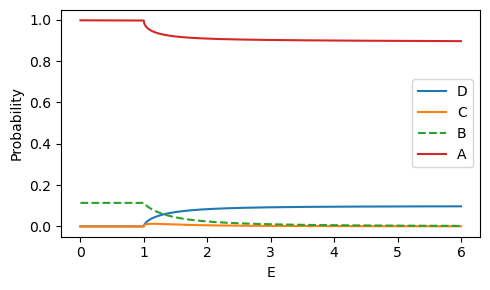

In [27]:
if __name__ == "__main__":
    u = 1000
    k = 0.000000001
    Z = 3
    c_val = u/1000
    
    E_set1 = np.linspace(0.001*c_val, 6*c_val, 10000)
    a_set1, b_set1, c_set1, d_set1, z_set1 = calculate_probabilities_new_method(u, k, Z, E_set1)
    
    
    # 绘图
    plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    #plt.plot(E_set1, z_set1, label='Z')
    plt.xlabel('E')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()

In [5]:
import numpy as np

# 示例：4元非齐次方程组
A = np.array([
    [1, 1j, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

b = np.array([7, 3j, 4, 5])

print("系数矩阵 A:")
print(A)
print(f"\n常数向量 b: {b}")
print(f"矩阵A的秩: {np.linalg.matrix_rank(A)}")

# 方法1: 使用 np.linalg.solve() (推荐)
try:
    x = np.linalg.solve(A, b)
    print(f"\n方法1 - np.linalg.solve() 解: {x}")
    print(f"验证 Ax = b: {np.allclose(A @ x, b)}")
except np.linalg.LinAlgError:
    print("矩阵A是奇异的，无法使用solve()")

# 方法2: 使用逆矩阵
if np.linalg.det(A) != 0:
    x_inv = np.linalg.inv(A) @ b
    print(f"方法2 - 逆矩阵法解: {x_inv}")
print(x[0])

系数矩阵 A:
[[1.+0.j 0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]

常数向量 b: [7.+0.j 0.+3.j 4.+0.j 5.+0.j]
矩阵A的秩: 4

方法1 - np.linalg.solve() 解: [10.+0.j  0.+3.j  4.+0.j  5.+0.j]
验证 Ax = b: True
方法2 - 逆矩阵法解: [10.+0.j  0.+3.j  4.+0.j  5.+0.j]
(10+0j)
